# Celda 1
## Mini Proyecto 3 – Clasificación de Pokémon con Transfer Learning

Clasificador de imágenes para 15 Pokémon usando ResNet50 y Transfer Learning.


# Celda 2
## Referencias


In [25]:
# Celda 3
# Esta celda instala todas las dependencias necesarias para el proyecto
# Incluye TensorFlow, kagglehub, scikit-learn y otras librerías necesarias

%pip install -q tensorflow kagglehub scikit-learn matplotlib numpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
# Celda 4
# Esta celda contiene todos los imports

import os
from pathlib import Path
import itertools

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import kagglehub

from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    f1_score, 
    balanced_accuracy_score,
    top_k_accuracy_score
)

import seaborn as sns

# Mostrar versiones para referencia
print("TensorFlow version:", tf.__version__)

# Fijar semilla para reproducibilidad básica
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow version: 2.20.0


# Celda 5
Descargamos data set

In [27]:
# Celda 6
# Descargar la última versión del dataset de Pokémon desde Kaggle
DATASET_PATH = kagglehub.dataset_download("lantian773030/pokemonclassification")
print("Ruta base del dataset descargado:", DATASET_PATH)

# Normalmente, las imágenes están dentro de la carpeta "PokemonData"
data_dir_full = os.path.join(DATASET_PATH, "PokemonData")
data_dir_full = Path(data_dir_full)

print("Directorio completo de imágenes:", data_dir_full)

# Listar todas las carpetas (clases) disponibles
all_subdirs = sorted([p.name for p in data_dir_full.iterdir() if p.is_dir()])
print("Número total de clases disponibles:", len(all_subdirs))

# SELECCIONAR SOLO 15 CLASES (requisito del proyecto)
NUM_CLASSES_TO_USE = 15
selected_classes = all_subdirs[:NUM_CLASSES_TO_USE]
print(f"\nSeleccionando las primeras {NUM_CLASSES_TO_USE} clases:")
for i, cls in enumerate(selected_classes, 1):
    print(f"  {i}. {cls}")

# Crear un directorio temporal con solo las 15 clases seleccionadas
import shutil
import tempfile

# Crear directorio temporal para las 15 clases
temp_data_dir = Path(tempfile.mkdtemp()) / "PokemonData_15classes"
temp_data_dir.mkdir(parents=True, exist_ok=True)

# Copiar solo las carpetas de las 15 clases seleccionadas
for cls_name in selected_classes:
    src = data_dir_full / cls_name
    dst = temp_data_dir / cls_name
    if src.exists():
        shutil.copytree(src, dst)
        print(f"Copiada clase: {cls_name}")

data_dir = temp_data_dir
print(f"\nDirectorio de trabajo (15 clases): {data_dir}")
print(f"Número de clases seleccionadas: {len(selected_classes)}")


Ruta base del dataset descargado: C:\Users\mcor2\.cache\kagglehub\datasets\lantian773030\pokemonclassification\versions\1
Directorio completo de imágenes: C:\Users\mcor2\.cache\kagglehub\datasets\lantian773030\pokemonclassification\versions\1\PokemonData
Número total de clases disponibles: 150

Seleccionando las primeras 15 clases:
  1. Abra
  2. Aerodactyl
  3. Alakazam
  4. Alolan Sandslash
  5. Arbok
  6. Arcanine
  7. Articuno
  8. Beedrill
  9. Bellsprout
  10. Blastoise
  11. Bulbasaur
  12. Butterfree
  13. Caterpie
  14. Chansey
  15. Charizard
Copiada clase: Abra
Copiada clase: Aerodactyl
Copiada clase: Alakazam
Copiada clase: Alolan Sandslash
Copiada clase: Arbok
Copiada clase: Arcanine
Copiada clase: Articuno
Copiada clase: Beedrill
Copiada clase: Bellsprout
Copiada clase: Blastoise
Copiada clase: Bulbasaur
Copiada clase: Butterfree
Copiada clase: Caterpie
Copiada clase: Chansey
Copiada clase: Charizard

Directorio de trabajo (15 clases): C:\Users\mcor2\AppData\Local\Temp\tm

# Celda 7
## Creación de datasets de entrenamiento y validación

División 80/20 con `image_dataset_from_directory`.


In [28]:
# Celda 8
# Parámetros de datos
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2  # 80/20

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Número de clases:", num_classes)

# Optimización de rendimiento de los datasets
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 563 files belonging to 15 classes.
Using 451 files for training.
Found 563 files belonging to 15 classes.
Using 112 files for validation.
Número de clases: 15


# Celda 9
## Visualización de ejemplos

Muestra imágenes del dataset de entrenamiento.


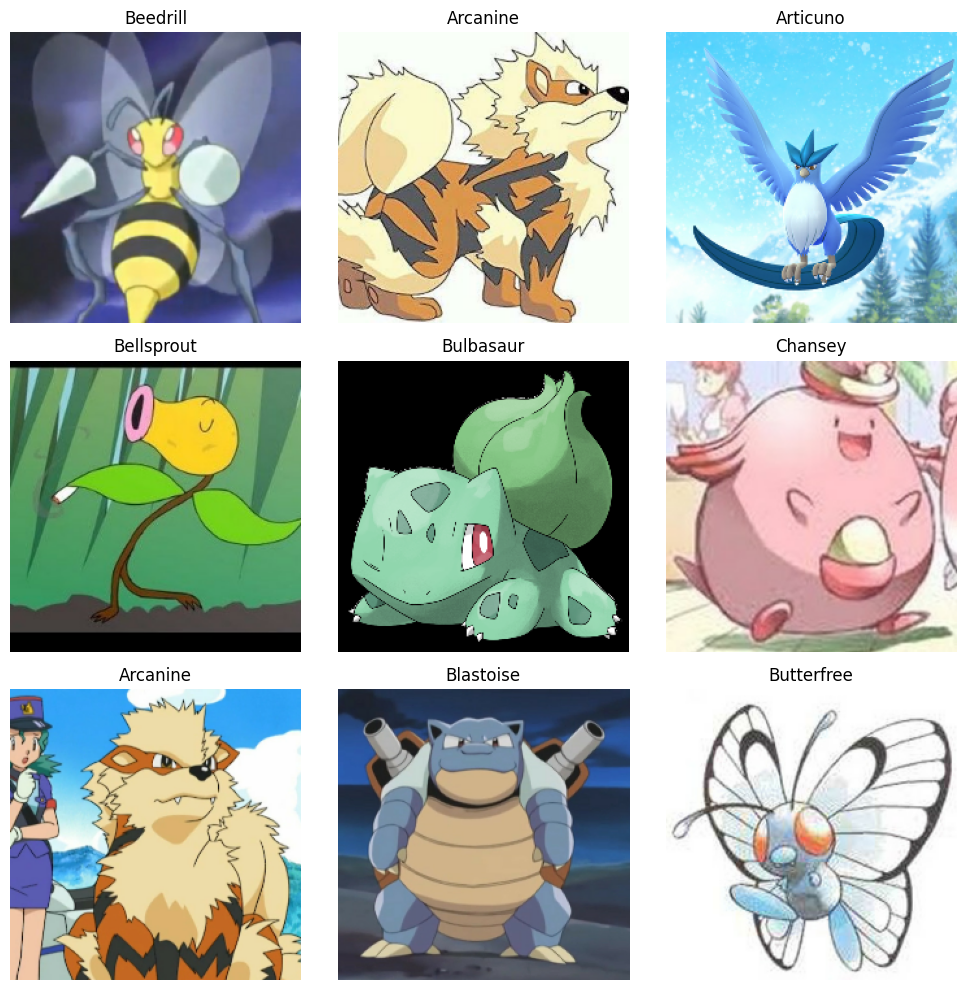

In [29]:
# Celda 10
# Obtener un batch de imágenes y etiquetas del conjunto de entrenamiento
image_batch, label_batch = next(iter(train_ds))

plt.figure(figsize=(10, 10))
for i in range(min(9, len(image_batch))):
    ax = plt.subplot(3, 3, i + 1)
    # Asegurar que las imágenes estén en el formato correcto para visualización
    img = image_batch[i].numpy()
    if img.max() <= 1.0:
        img = (img * 255).astype("uint8")
    else:
        img = img.astype("uint8")
    plt.imshow(img)
    label = class_names[label_batch[i]]
    plt.title(label)
    plt.axis("off")
plt.tight_layout()
plt.show()


# Celda 11
## Data Augmentation

Transformaciones aleatorias para aumentar la variabilidad de las imágenes.


In [30]:
# Celda 12
# Capa de Data Augmentation (se puede usar dentro del modelo)
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)


# Celda 13
## Definición del modelo ResNet50

Transfer Learning con ResNet50 preentrenada. Feature Extraction con capas congeladas.


# Celda 14
## Construcción del modelo

ResNet50 + capas densas para clasificación.


In [31]:
# Celda 15
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

# Cargar ResNet50 preentrenada sin la parte fully-connected superior
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

# Congelar las capas del modelo base (Feature Extraction)
base_model.trainable = False

# Construir el modelo completo
inputs = keras.Input(shape=IMG_SIZE + (3,), name="input_image")

# Data augmentation
x = data_augmentation(inputs)

# Preprocesamiento específico de ResNet50
x = preprocess_input(x)

# Extracción de características con la base convolucional
x = base_model(x, training=False)

# Pooling global para reducir dimensionalidad
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)

# Capa densa final con Dropout para regularización
x = layers.Dropout(0.3, name="dropout")(x)

outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="pokemon_resnet50")

# Resumen del modelo
model.summary()


Model: "pokemon_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 224, 224,  │          0 │ get_item_6[0][0], │
│                     │ 3)                │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 224, 224,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_2[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 15)        │     30,735 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,618,447 (90.10 MB)

 Trainable params: 30,735 (120.06 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Celda 16
## Compilación y entrenamiento

Feature Extraction: solo se entrena la cabeza de clasificación.


In [32]:
# Celda 17
# Compilar el modelo
# Para CNN con muchas clases, usamos métricas más apropiadas:
# - Top-K Accuracy (Top-3, Top-5) es estándar en visión por computadora
# - Accuracy sigue siendo útil pero puede ser engañosa con clases desbalanceadas
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top_3_accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top_5_accuracy"),
    ],
)

# Callbacks mejorados
# EarlyStopping: detiene el entrenamiento cuando no hay mejora y restaura los mejores pesos
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_top_3_accuracy",  # Usar top_3_accuracy como métrica principal
    patience=5,  # Esperar 5 épocas sin mejora
    restore_best_weights=True,  # Restaurar los mejores pesos al finalizar
    verbose=1,
    mode="max"  # Maximizar la métrica
)

# ModelCheckpoint: guarda el modelo con el mejor desempeño
checkpoint_path = "best_pokemon_resnet50_feature_extraction.keras"
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_top_3_accuracy",  # Guardar basado en top_3_accuracy
    save_best_only=True,  # Solo guardar el mejor modelo
    save_weights_only=False,  # Guardar el modelo completo
    verbose=1,
    mode="max"
)

# Número máximo de épocas (EarlyStopping decidirá cuándo parar)
EPOCHS = 30  # Máximo de épocas, pero EarlyStopping puede parar antes

print(f"Entrenando modelo con máximo {EPOCHS} épocas...")
print("EarlyStopping monitoreará 'val_top_3_accuracy' y parará si no hay mejora en 5 épocas.")
print("El mejor modelo se guardará automáticamente en:", checkpoint_path)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint_cb],
    verbose=1
)

print(f"\nEntrenamiento completado después de {len(history.history['loss'])} épocas.")
print(f"Mejor val_top_3_accuracy: {max(history.history['val_top_3_accuracy']):.4f}")


Entrenando modelo con máximo 30 épocas...
EarlyStopping monitoreará 'val_top_3_accuracy' y parará si no hay mejora en 5 épocas.
El mejor modelo se guardará automáticamente en: best_pokemon_resnet50_feature_extraction.keras
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1405 - loss: 3.1743 - top_3_accuracy: 0.3159 - top_5_accuracy: 0.4660
Epoch 1: val_top_3_accuracy improved from None to 0.69643, saving model to best_pokemon_resnet50_feature_extraction.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.2106 - loss: 2.7848 - top_3_accuracy: 0.4124 - top_5_accuracy: 0.5654 - val_accuracy: 0.4464 - val_loss: 1.7776 - val_top_3_accuracy: 0.6964 - val_top_5_accuracy: 0.7857
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5014 - loss: 1.5961 - top_3_accuracy: 0.7869 - top_5_accuracy: 0.8591
Epoch 2: val_top_3_accuracy improved from 0.69643 to 0.86607, saving model to best_pokemon_resnet50_feature_extraction.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - 

# Celda 18
## Carga del mejor modelo

Carga el mejor modelo guardado por ModelCheckpoint para usar en evaluaciones y fine-tuning.


In [33]:
# Celda 18
# Cargar el mejor modelo guardado por ModelCheckpoint (Feature Extraction)

from tensorflow.keras.models import load_model

print("Cargando el mejor modelo guardado en el checkpoint...")

best_model = load_model(checkpoint_path)

print("Resumen del modelo cargado (best_model):")

best_model.summary()


Cargando el mejor modelo guardado en el checkpoint...
Resumen del modelo cargado (best_model):


Model: "pokemon_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 224, 224,  │          0 │ get_item_6[0][0], │
│                     │ 3)                │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 224, 224,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_2[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 15)        │     30,735 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,679,919 (90.33 MB)

 Trainable params: 30,735 (120.06 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 61,472 (240.13 KB)

# Celda 19
## Fine-Tuning

Ajuste fino de las últimas capas de ResNet50 usando el mejor modelo guardado.


Capas totales en la base ResNet50: 175
Descongelando desde la capa 145 hasta el final para fine-tuning.
Iniciando fine-tuning por hasta 10 épocas...
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8569 - loss: 0.4964 - top_3_accuracy: 0.9744 - top_5_accuracy: 1.0000
Epoch 1: val_top_3_accuracy improved from None to 0.98214, saving model to best_pokemon_resnet50_finetuned.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.8803 - loss: 0.4565 - top_3_accuracy: 0.9778 - top_5_accuracy: 1.0000 - val_accuracy: 0.9375 - val_loss: 0.3130 - val_top_3_accuracy: 0.9821 - val_top_5_accuracy: 0.9821
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9230 - loss: 0.3477 - top_3_accuracy: 0.9858 - top_5_accuracy: 0.9976
Epoch 2: val_top_3_accuracy did not improve from 0.98214
15/15 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9246 - loss: 0.3346 - top_3_accuracy: 0.9911 - top_5_accuracy: 0.9978 - val_accuracy: 0.9375 - val_loss: 0.2737 - val_top_3_accuracy: 0.982

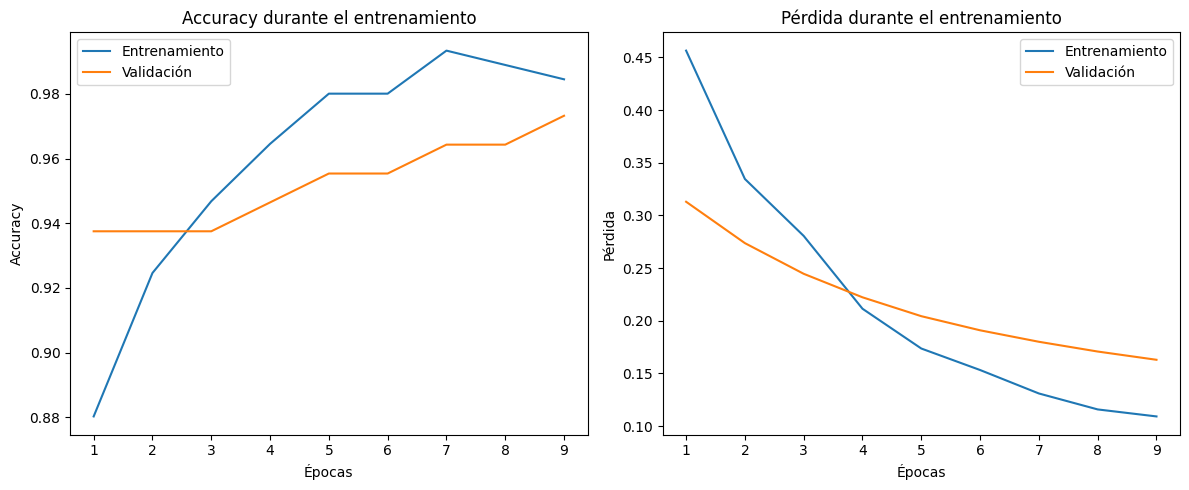

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9464 - loss: 0.2223 - top_3_accuracy: 0.9911 - top_5_accuracy: 0.9911
[Fine-Tuning] Loss en validación: 0.2223
[Fine-Tuning] Accuracy (Top-1) en validación: 94.6429%
[Fine-Tuning] Top-3 Accuracy en validación: 99.1071%
[Fine-Tuning] Top-5 Accuracy en validación: 99.1071%


In [34]:
# Celda 20
# Fine-Tuning de las capas superiores de ResNet50 usando el mejor modelo guardado

# 1. Obtenemos la base convolucional (ResNet50) dentro de best_model
base_model_ft = best_model.get_layer("resnet50")
print("Capas totales en la base ResNet50:", len(base_model_ft.layers))

# 2. Descongelar solo las últimas N capas de ResNet50 (por ejemplo, 30)
fine_tune_at = len(base_model_ft.layers) - 30
base_model_ft.trainable = True
for layer in base_model_ft.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Descongelando desde la capa {fine_tune_at} hasta el final para fine-tuning.")

# 3. Recompilar best_model con un learning rate pequeño
best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top_3_accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top_5_accuracy"),
    ],
)

# 4. Callbacks específicos para fine-tuning
checkpoint_path_ft = "best_pokemon_resnet50_finetuned.keras"
checkpoint_cb_ft = keras.callbacks.ModelCheckpoint(
    checkpoint_path_ft,
    monitor="val_top_3_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
    mode="max",
)

early_stop_ft = keras.callbacks.EarlyStopping(
    monitor="val_top_3_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1,
    mode="max",
)

fine_tune_epochs = 10
print(f"Iniciando fine-tuning por hasta {fine_tune_epochs} épocas...")
history_fine = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=[early_stop_ft, checkpoint_cb_ft],
    verbose=1,
)

print("\nFine-tuning completado.")

# Visualizar curvas de entrenamiento del fine-tuning
def plot_training_curves(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Entrenamiento")
    plt.plot(epochs_range, val_acc, label="Validación")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.title("Accuracy durante el entrenamiento")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Entrenamiento")
    plt.plot(epochs_range, val_loss, label="Validación")
    plt.xlabel("Épocas")
    plt.ylabel("Pérdida")
    plt.title("Pérdida durante el entrenamiento")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(history_fine)

# 5. Evaluar el modelo afinado
eval_results_ft = best_model.evaluate(val_ds, verbose=1)
print(f"[Fine-Tuning] Loss en validación: {eval_results_ft[0]:.4f}")
print(f"[Fine-Tuning] Accuracy (Top-1) en validación: {eval_results_ft[1]:.4%}")
print(f"[Fine-Tuning] Top-3 Accuracy en validación: {eval_results_ft[2]:.4%}")
print(f"[Fine-Tuning] Top-5 Accuracy en validación: {eval_results_ft[3]:.4%}")


# Celda 22
## Evaluación del modelo

Métricas para CNN multiclase: Top-K Accuracy, F1-score, Balanced Accuracy, matriz de confusión.


In [ ]:
# Celda 23
# 1. Evaluación global con métricas del modelo
print("=" * 60)
print("EVALUACIÓN DEL MODELO - MÉTRICAS PARA CNN MULTICLASE")
print("=" * 60)
eval_results = best_model.evaluate(val_ds, verbose=1)
val_loss = eval_results[0]
val_acc = eval_results[1]
val_top3_acc = eval_results[2]
val_top5_acc = eval_results[3]

print(f"\n{'Métrica':<30} {'Valor':<15}")
print("-" * 45)
print(f"{'Loss':<30} {val_loss:.4f}")
print(f"{'Accuracy (Top-1)':<30} {val_acc:.4%}")
print(f"{'Top-3 Accuracy':<30} {val_top3_acc:.4%}")
print(f"{'Top-5 Accuracy':<30} {val_top5_acc:.4%}")

# 2. Obtener predicciones y etiquetas verdaderas de forma eficiente
print("\n" + "=" * 60)
print("OBTENIENDO PREDICCIONES...")
print("=" * 60)
y_pred_probs = best_model.predict(val_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Obtener las etiquetas verdaderas de forma correcta
y_true_list = []
for images, labels in val_ds:
    y_true_list.append(labels.numpy())
y_true = np.concatenate(y_true_list, axis=0)

# Asegurar que las predicciones y etiquetas tengan la misma longitud
min_length = min(len(y_true), len(y_pred))
y_true = y_true[:min_length]
y_pred = y_pred[:min_length]

print(f"Número de muestras: {len(y_true)}")
print(f"Número de clases: {num_classes}")

# 3. Calcular métricas adicionales apropiadas para CNN con muchas clases
print("\n" + "=" * 60)
print("MÉTRICAS ADICIONALES PARA CNN MULTICLASE")
print("=" * 60)

# Top-K Accuracy usando sklearn (verificación adicional)
top3_acc_sklearn = top_k_accuracy_score(y_true, y_pred_probs, k=3)
top5_acc_sklearn = top_k_accuracy_score(y_true, y_pred_probs, k=5)

# Macro y Micro F1-score
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0, labels=np.arange(num_classes))
micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0, labels=np.arange(num_classes))

# Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_true, y_pred)

print(f"\n{'Métrica':<35} {'Valor':<15}")
print("-" * 50)
print(f"{'Top-3 Accuracy (sklearn)':<35} {top3_acc_sklearn:.4%}")
print(f"{'Top-5 Accuracy (sklearn)':<35} {top5_acc_sklearn:.4%}")
print(f"{'Macro-averaged F1-score':<35} {macro_f1:.4f}")
print(f"{'Micro-averaged F1-score':<35} {micro_f1:.4f}")
print(f"{'Balanced Accuracy':<35} {balanced_acc:.4%}")

print("\n" + "-" * 60)
print("EXPLICACIÓN DE LAS MÉTRICAS:")
print("-" * 60)
print("• Top-K Accuracy: Porcentaje de casos donde la clase correcta está")
print("  entre las K predicciones más probables (estándar en visión por computadora).")
print("• Macro F1-score: Promedio no ponderado de F1 por clase.")
print("  Útil cuando hay desbalance entre clases.")
print("• Micro F1-score: F1 calculado globalmente (equivalente a accuracy cuando hay balance).")
print("• Balanced Accuracy: Promedio del recall por clase.")
print("  Mejor que accuracy cuando hay clases desbalanceadas.")
print("-" * 60)

# 4. Matriz de confusión
print("\n" + "=" * 60)
print("MATRIZ DE CONFUSIÓN")
print("=" * 60)
cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))
print(f"Tamaño de la matriz de confusión: {cm.shape}")
print(f"Esperado: ({num_classes}, {num_classes})")

# 5. Reporte de clasificación
print("\n" + "=" * 60)
print("REPORTE DE CLASIFICACIÓN POR CLASE")
print("=" * 60)
report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0
)
print(report)

# === Matriz de confusión en formato gráfico (heatmap) ===
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión – Validación (ResNet50 Transfer Learning)")
plt.tight_layout()
plt.show()


EVALUACIÓN DEL MODELO - MÉTRICAS PARA CNN MULTICLASE
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 984ms/step - accuracy: 0.9554 - loss: 0.2674 - top_3_accuracy: 1.0000 - top_5_accuracy: 1.0000

Métrica                        Valor          
---------------------------------------------
Loss                           0.2674
Accuracy (Top-1)               95.5357%
Top-3 Accuracy                 100.0000%
Top-5 Accuracy                 100.0000%

OBTENIENDO PREDICCIONES...
3/4 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/stepWARNING:tensorflow:5 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000230EAFCCAE0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracin

# Celda 24
## Visualización de predicciones

Ejemplos de imágenes con predicciones vs etiquetas reales.


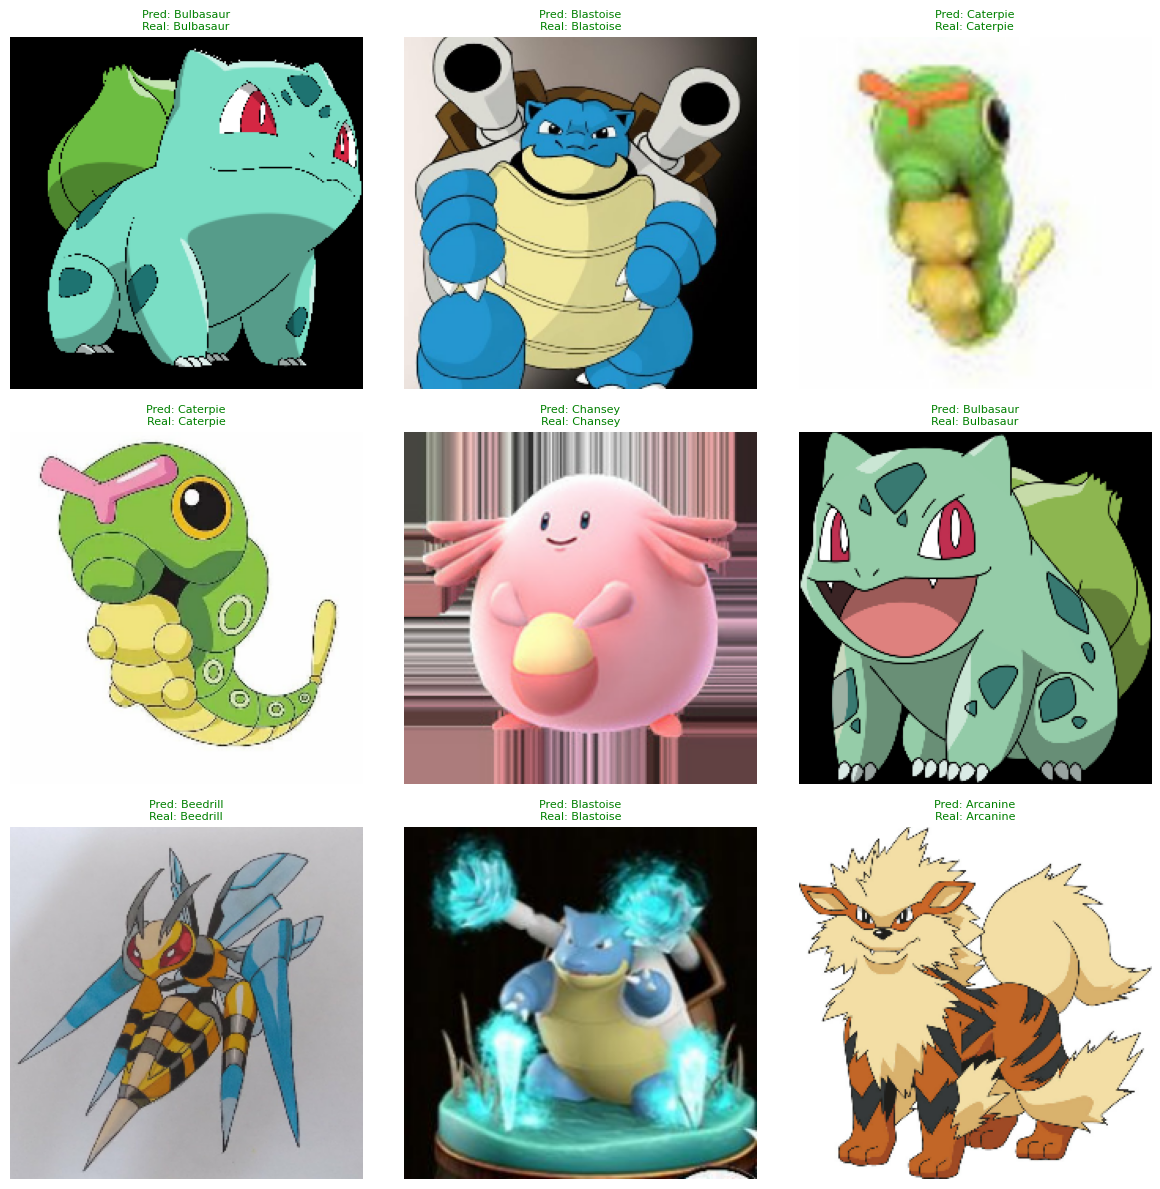

In [ ]:
# Celda 25
# Visualización de predicciones vs etiquetas reales
# Tomar de nuevo un batch de validación
val_images, val_labels = next(iter(val_ds))

pred_probs = best_model.predict(val_images, verbose=0)
pred_indices = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(12, 12))
for i in range(min(9, len(val_images))):
    ax = plt.subplot(3, 3, i + 1)
    # Las imágenes del dataset están en rango [0, 255] como uint8
    # Asegurarse de que estén en el formato correcto para visualización
    img = val_images[i].numpy()
    if img.max() <= 1.0:
        img = (img * 255).astype("uint8")
    else:
        img = img.astype("uint8")
    plt.imshow(img)

    true_label = class_names[val_labels[i]]
    pred_label = class_names[pred_indices[i]]
    
    # Colorear el título según si la predicción es correcta
    color = "green" if true_label == pred_label else "red"
    title = f"Pred: {pred_label}\nReal: {true_label}"
    plt.title(title, fontsize=8, color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()


# Celda 26
## Conclusiones

Resumen del proyecto y objetivos cumplidos.
